<a href="https://colab.research.google.com/github/samidzaman/Image_Classification_Model_DL/blob/main/Fashion_MINIST_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

In [53]:
torch.manual_seed(42)

In [54]:
#CPU to GPU
#Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [55]:
df = pd.read_csv("fmnist_small.csv")

In [56]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


# Image hocce akta 2D Array, Dataset a atake 1D kore dewa thake , shekhan theke Image show koranu,, abar 2D te niye  (Basic Grap)

In [57]:
#kunu array theke element ar nam o tar index ber kora hoy enumerate diye
fruits = ['Apple', 'Banana', 'Lichi']

for index , fruit in enumerate(fruits):
  print(index, fruit)

0 Apple
1 Banana
2 Lichi


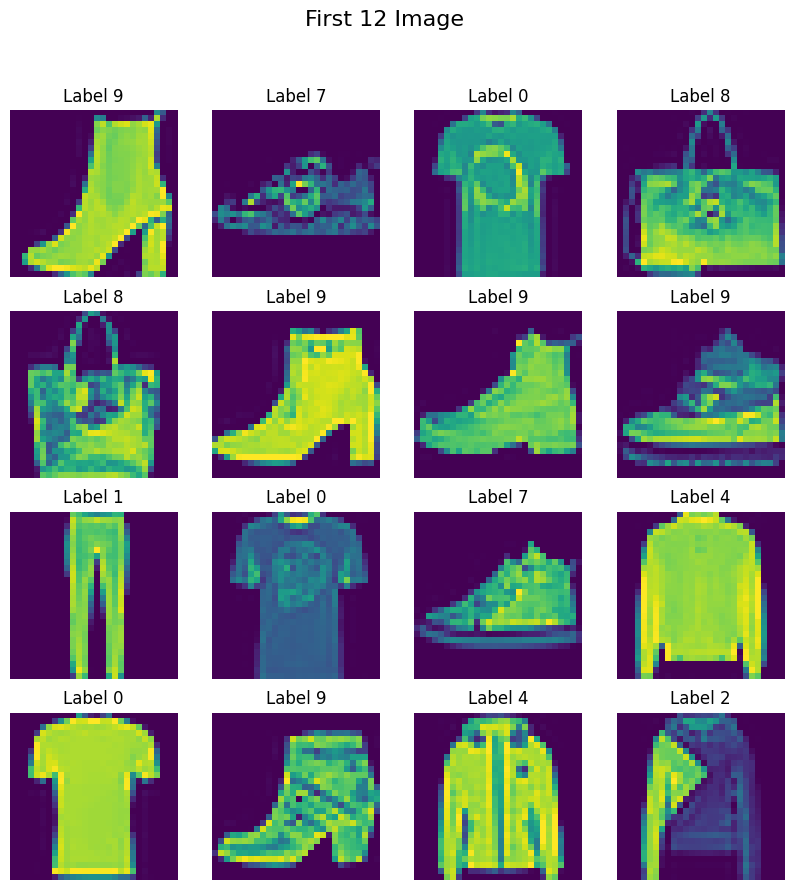

In [58]:
#amra 12ta Image dekhbo
#first a akta subplot create korbo
fig , axes = plt.subplots(4, 4 , figsize=(10,10))
plt.suptitle("First 12 Image", fontsize=(16))

#enumerate kore image ber kora

for i, ax in enumerate(axes.flat):
  img = df.iloc[i, 1: ].values.reshape(28,28)
  ax.imshow(img)
  #axis ar upor theke roler soranu
  ax.axis('off')

  #protita image ar upor nam bosanu
  ax.set_title(f"Label {df.iloc[i, 0 ]}")


# Architecture (input layer mane sob feture, outputlayer mane label koyta(2ta cls naki multipole), multipole cls ar jonno softmax activation fn use , hidden layer a RELU use )

In [59]:
#Train Test a vag
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values


In [60]:
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
#scaling
X_train = X_train / 255.0
X_test = X_test / 255.0


# Creating CoustomDataset

In [62]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    #mone rakhbo feature dtype float and target/label dtype long
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]


In [63]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [64]:
len(train_dataset), len(test_dataset)

(4800, 1200)

In [65]:
# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

# Define ANN  Model

In [66]:
class Mynn(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  #forwad fun
  def forward(self, x):
    return self.model(x)


# Instantiate Model

In [67]:
epochs = 10
learning_rate = 0.1

In [72]:
model = Mynn(X_train.shape[1])
#CPU to GPU Convert
model= model.to(device)


In [73]:
#loss function (Categorical loss fun)
critarion = nn.CrossEntropyLoss()



In [74]:
#optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Training loop

In [75]:
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:

    #Convert CPU to GPU
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    #forward pass
    output = model(batch_features)

    #loss calculate
    loss = critarion(output, batch_labels)

    #backward
    optimizer.zero_grad()
    loss.backward()

    #Weight update
    optimizer.step()

    #protita epoch a ki poriman loss hocce tar avg dekha

    total_epoch_loss = total_epoch_loss + loss.item()


avg_loss = total_epoch_loss / len(train_loader)
print(avg_loss)


0.41066191643476485


# Model Evaluation

In [76]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:

    #CPU to GPU Convert
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    #forward pass
    output = model(batch_features)

    #amra shudu shotik predicted gulo dekhbo
    _, predicted = torch.max(output,1)
    # print(f"predicted {predicted}")

    #total
    total = total + batch_labels.shape[0]

    #correct
    correct = correct + (predicted == batch_labels).sum().item()

print(f"Accuracy {correct/total}")

Accuracy 0.8216666666666667
